In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import subprocess


PROJECT_ROOT = "/home/pessoa/Codes/Celegans_inference"
sys.path.insert(0, PROJECT_ROOT)


In [2]:
#This files assumes that you have already run the calibrate_capacity.py script, which outputs two .npz files.
#Edit the paths below to match your filenames. The first file contains the capacity estimates, and the second file contains the kappa samples from the ABC procedure.

# Cell 1 — Convenience paths (edit to match your filenames)

CAPACITY_REPOP_NPZ = os.path.join(PROJECT_ROOT, "capacity_day9_repop_precalibration_lowpH.npz")
KAPPA_SAMPLES_STRAT_NPZ  = os.path.join(PROJECT_ROOT, "kappa_samples_stratified_lowpH.npz")  

# CAPACITY_REPOP_NPZ = os.path.join(PROJECT_ROOT, "capacity_day9_repop_precalibration_highpH.npz")
# KAPPA_SAMPLES_STRAT_NPZ  = os.path.join(PROJECT_ROOT, "kappa_samples_stratified_highpH.npz")  


kappa range: (np.float64(0.0), np.float64(266400.0)) len: 266401
p sum: 1.0


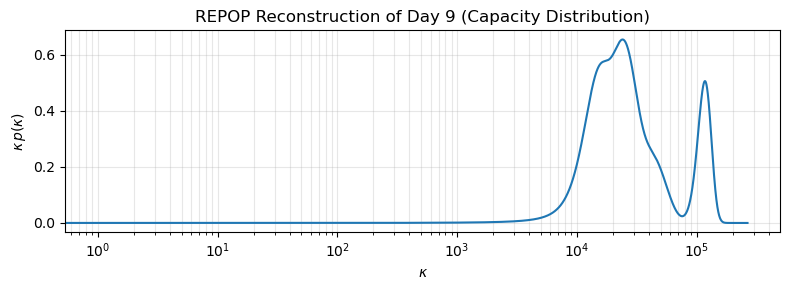

In [3]:
# Cell 2 — Load and plot the reconstructed Day-9 capacity distribution (should have 4 Guassians)

dat = np.load(CAPACITY_REPOP_NPZ)
kappa = dat["kappa"].astype(np.float64).reshape(-1)
p     = dat["p"].astype(np.float64).reshape(-1)
p     = p / p.sum()

# Sanity
print("kappa range:", (kappa.min(), kappa.max()), "len:", len(kappa))
print("p sum:", p.sum())

# Plot as a line (discrete PMF; line is fine for visualization)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(kappa, kappa * p, lw=1.5)

ax.set_xscale("log")
ax.set_xlabel(r"$\kappa$")
ax.set_ylabel(r"$\kappa\,p(\kappa)$")
ax.set_title("REPOP Reconstruction of Day 9 (Capacity Distribution)")

ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Cell 3 — Load and plot the reconstructed Day-9 capacity distribution (should have 4 Guassians)

print("Total probability:", np.sum(p))
print("Mean capacity:", np.sum(kappa * p))
print("Median capacity:",
      kappa[np.searchsorted(np.cumsum(p), 0.5)])


Total probability: 1.0
Mean capacity: 38943.67394106427
Median capacity: 23995.0


In [5]:
# Cell 4 — Load samples and compare
sd = np.load(KAPPA_SAMPLES_STRAT_NPZ)
kappa_samples = sd["kappa_samples"].astype(np.float64).reshape(-1)
print("Num samples:", len(kappa_samples), "range:", (kappa_samples.min(), kappa_samples.max()))



Num samples: 1048576 range: (np.float64(1001.0), np.float64(183613.0))


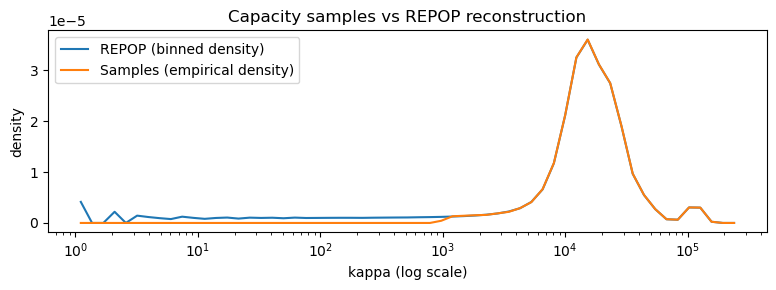

In [6]:
# Cell 5 — Compare empirical sample distribution to REPOP reconstruction
# Use log-spaced bins so the tail is visible.
kmin = max(1.0, min(kappa[kappa > 0].min(), kappa_samples[kappa_samples > 0].min()))
kmax = max(kappa.max(), kappa_samples.max())

nbins = 60
bins = np.logspace(np.log10(kmin), np.log10(kmax), nbins)

# Empirical density of sampled kappas
hist_samp, edges = np.histogram(kappa_samples, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])

# REPOP "density" approximated on same bins:
# Since REPOP is a discrete pmf on integer kappa, we approximate bin mass by summing p where kappa in bin,
# then divide by bin width to get a comparable density.
hist_rep = np.zeros_like(hist_samp, dtype=np.float64)
for i in range(len(edges) - 1):
    lo, hi = edges[i], edges[i+1]
    mask = (kappa >= lo) & (kappa < hi)
    mass = p[mask].sum()
    width = hi - lo
    hist_rep[i] = mass / width if width > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(centers, hist_rep, label="REPOP (binned density)")
ax.plot(centers, hist_samp, label="Samples (empirical density)")
ax.set_xscale("log")
ax.set_xlabel("kappa (log scale)")
ax.set_ylabel("density")
ax.set_title("Capacity samples vs REPOP reconstruction")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_158089/1071501912.py:7: RuntimeWarning: divide by zero encountered in log10
  q_rep = np.quantile(np.log10(repop_draw), qs)


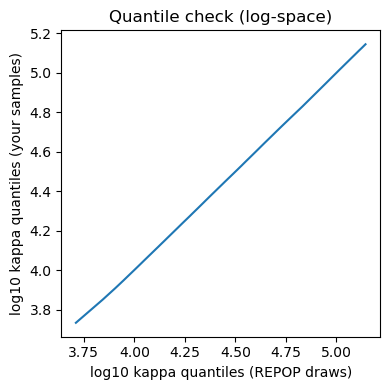

In [7]:
# Cell 6 — Quick quantile comparison in log-space (optional)
# Sample from REPOP pmf directly for a fair quantile overlay
rng = np.random.default_rng(0)
repop_draw = rng.choice(kappa, size=len(kappa_samples), replace=True, p=p)

qs = np.linspace(0.01, 0.99, 99)
q_rep = np.quantile(np.log10(repop_draw), qs)
q_sam = np.quantile(np.log10(kappa_samples), qs)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(q_rep, q_sam)
ax.set_xlabel("log10 kappa quantiles (REPOP draws)")
ax.set_ylabel("log10 kappa quantiles (your samples)")
ax.set_title("Quantile check (log-space)")
plt.tight_layout()
plt.show()


In [8]:
# Cell 7 — Run a small simulation for trajectory visualization
from utils import simulator
import numpy as np
import torch

# ----------------------------
# Device and simulation config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = 256                 # number of trajectories
T_end = 216.0           # hours
dt_record = 0.2         # hours

record_times = torch.arange(
    dt_record,
    T_end + 1e-9,
    dt_record,
    device=device,
)

# ----------------------------
# Load stratified kappa samples
# ----------------------------
data = np.load(KAPPA_SAMPLES_STRAT_NPZ)
kappa_all = data["kappa_samples"]   # adjust key if needed

assert kappa_all.ndim == 1
assert len(kappa_all) >= N

# Choose N kappas to use for simulating (deterministic or random)
rng = np.random.default_rng(0)
kappa_smallsample = rng.choice(kappa_all, size=N, replace=False)

# Move to torch
kappa_smallsample = torch.tensor(kappa_smallsample, dtype=torch.float32, device=device)

# ----------------------------
# Parameters
# ----------------------------
alpha = 0.02
mu    = 0.5
d = 0.001
#d     = 0.01*mu

params = torch.stack([
    torch.full((N,), alpha, device=device),
    torch.full((N,), mu,    device=device),
    kappa_smallsample,                          # per-trajectory κ
    torch.full((N,), d,     device=device),
], dim=0)   # shape (4, N)

assert params.shape == (4, N)

# ----------------------------
# Run simulator
# ----------------------------
snapshots = simulator.sample_record(
    params=params,
    record_times=record_times,
    N=N,
    device=device,
)

# Stack results
E_mat = torch.stack([s.to("cpu") for s in snapshots], dim=0).numpy()
t_vec = record_times.to("cpu").numpy()

print("E_mat shape:", E_mat.shape)   # (Trec, N)


E_mat shape: (1080, 256)


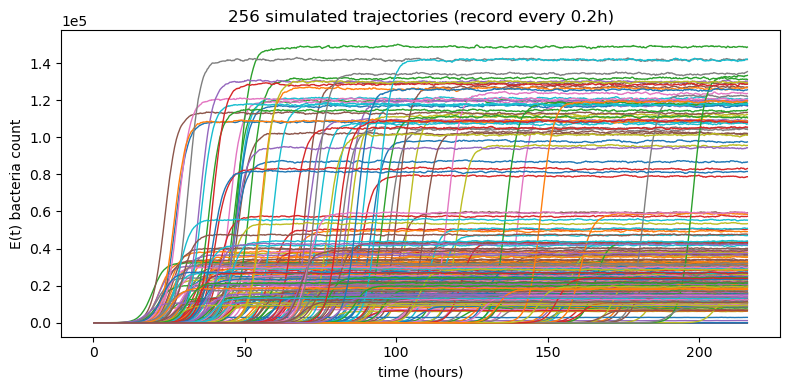

In [9]:
# Cell 8 — Plot all trajectories
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(E_mat.shape[1]):
    ax.plot(t_vec, E_mat[:, i], linewidth=1)

ax.set_xlabel("time (hours)")
ax.set_ylabel("E(t) bacteria count")
ax.set_title("256 simulated trajectories (record every 0.2h)")
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useOffset=False)
plt.tight_layout()
plt.show()


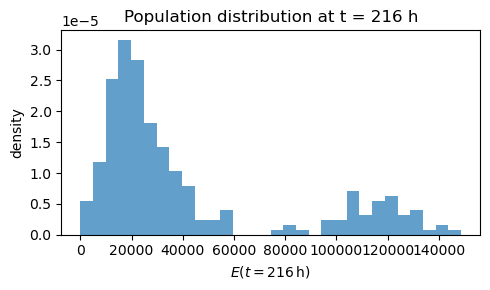

In [10]:
# Cell 9 — Final-time populations across trajectories
E_final = E_mat[-1, :]   # shape (N,)

plt.figure(figsize=(5, 3))
plt.hist(E_final, bins=30, density=True, alpha=0.7)
plt.xlabel(r"$E(t=216\,\mathrm{h})$")
plt.ylabel("density")
plt.title("Population distribution at t = 216 h")
plt.tight_layout()
plt.show()



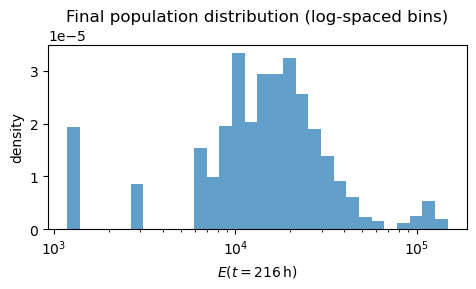

In [11]:
import numpy as np
import matplotlib.pyplot as plt

E_final = E_mat[-1, :]

# Exclude zeros (log bins cannot include 0)
E_pos = E_final[E_final > 0]

# Define LOG-SPACED bins
nbins = 30
bins = np.logspace(
    np.log10(E_pos.min()),
    np.log10(E_pos.max()),
    nbins + 1
)

plt.figure(figsize=(5, 3))
plt.hist(E_pos, bins=bins, density=True, alpha=0.7)

plt.xscale("log")
plt.xlabel(r"$E(t=216\,\mathrm{h})$")
plt.ylabel("density")
plt.title("Final population distribution (log-spaced bins)")
plt.tight_layout()
plt.show()


In [12]:
# Since many trajectories stay 0 even at the end, let's check the issue of extinction
E_final = E_mat[-1, :]
print("Extinction fraction:", (E_final == 0).mean())

kappa_np = kappa_smallsample.detach().cpu().numpy()
E_final = E_mat[-1, :]

# Compare κ between extinct vs non-extinct
print("κ median (E_final==0):", np.median(kappa_np[E_final == 0]) if (E_final==0).any() else None)
print("κ median (E_final>0):",  np.median(kappa_np[E_final > 0])  if (E_final>0).any() else None)

ever_nonzero = (E_mat > 0).any(axis=0)
print("Ever became nonzero:", ever_nonzero.mean())


Extinction fraction: 0.01953125
κ median (E_final==0): 96058.0
κ median (E_final>0): 24992.0
Ever became nonzero: 0.98046875


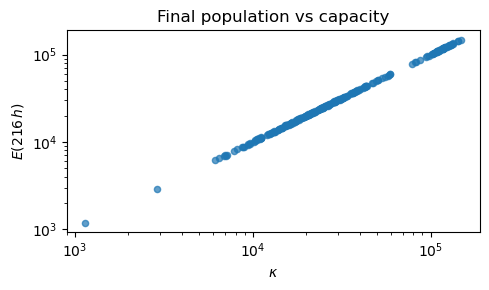

In [13]:
kappa_np = kappa_smallsample.detach().cpu().numpy()
E_final = E_mat[-1, :]

plt.figure(figsize=(5,3))
plt.scatter(kappa_np, E_final, s=20, alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\kappa$")
plt.ylabel(r"$E(216\,h)$")
plt.title("Final population vs capacity")
plt.tight_layout()
plt.show()


In [14]:
print("min kappa:", kappa.min(), "max kappa:", kappa.max())
print("mass at kappa=0:", p[kappa == 0].sum() if np.any(kappa == 0) else 0.0)
print("mass at kappa=1:", p[kappa == 1].sum() if np.any(kappa == 1) else 0.0)


min kappa: 0.0 max kappa: 266400.0
mass at kappa=0: 9.767961312801229e-07
mass at kappa=1: 9.76992827529332e-07


In [15]:
def time_index(t_vec, t_target):
    return int(np.argmin(np.abs(t_vec - t_target)))

idx_24  = time_index(t_vec, 24.0)
idx_72  = time_index(t_vec, 72.0)
idx_120 = time_index(t_vec, 120.0)
idx_168 = time_index(t_vec, 168.0)
idx_216 = time_index(t_vec, 216.0)

print(idx_24, idx_72, idx_120, idx_168, idx_216)
print(t_vec[idx_24], t_vec[idx_72], t_vec[idx_120], t_vec[idx_168], t_vec[idx_216])


119 359 599 839 1079
24.0 72.0 120.0 168.0 216.0


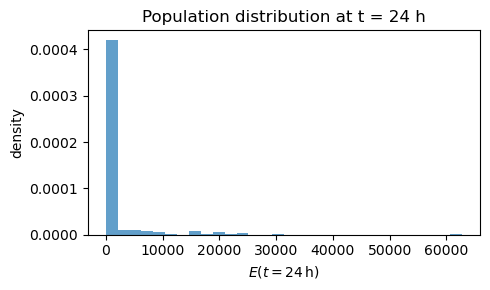

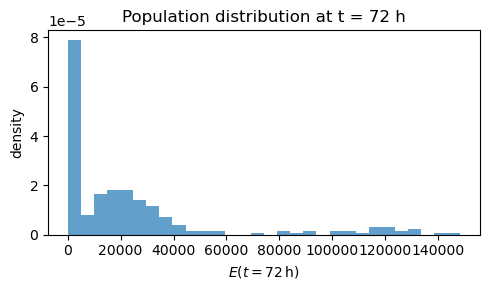

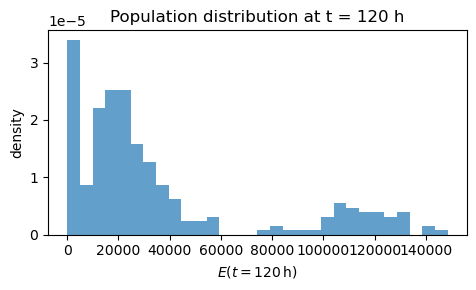

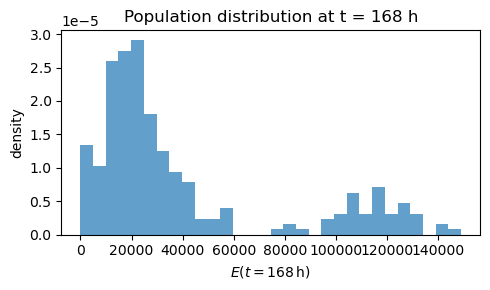

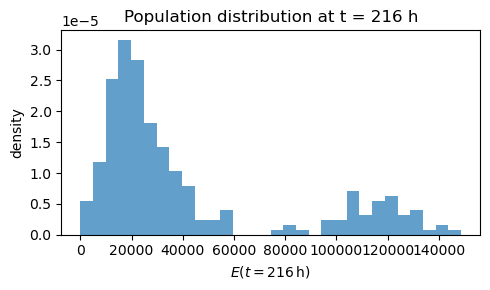

In [16]:
import matplotlib.pyplot as plt

for t_label, idx in [(24, idx_24), (72, idx_72), (120, idx_120), (168, idx_168), (216, idx_216)]:
    E_t = E_mat[idx, :]

    plt.figure(figsize=(5, 3))
    plt.hist(E_t, bins=30, density=True, alpha=0.7)
    plt.xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
    plt.ylabel("density")
    plt.title(f"Population distribution at t = {t_label} h")
    plt.tight_layout()
    plt.show()


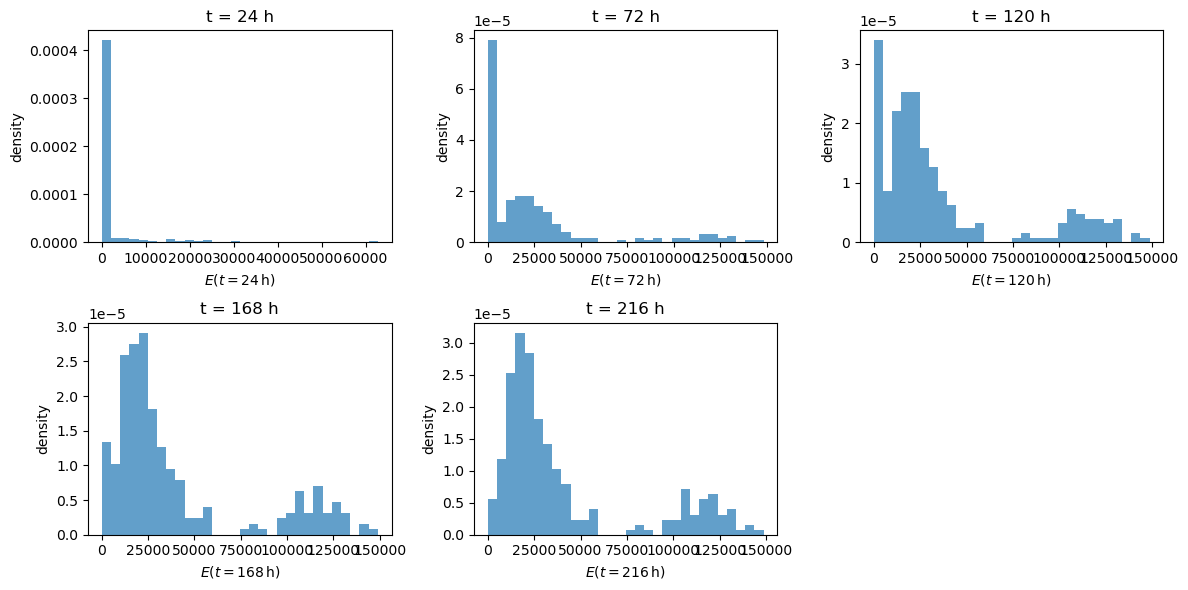

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 3, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),  
    fig.add_subplot(gs[1, 1]),
]

time_info = [
    (24,  idx_24),
    (72,  idx_72),
    (120, idx_120),
    (168, idx_168),
    (216, idx_216),
]

for ax, (t_label, idx) in zip(axes, time_info):
    E_t = E_mat[idx, :]

    ax.hist(E_t, bins=30, density=True, alpha=0.7)
    ax.set_xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
    ax.set_ylabel("density")
    ax.set_title(f"t = {t_label} h")

plt.tight_layout()
plt.show()


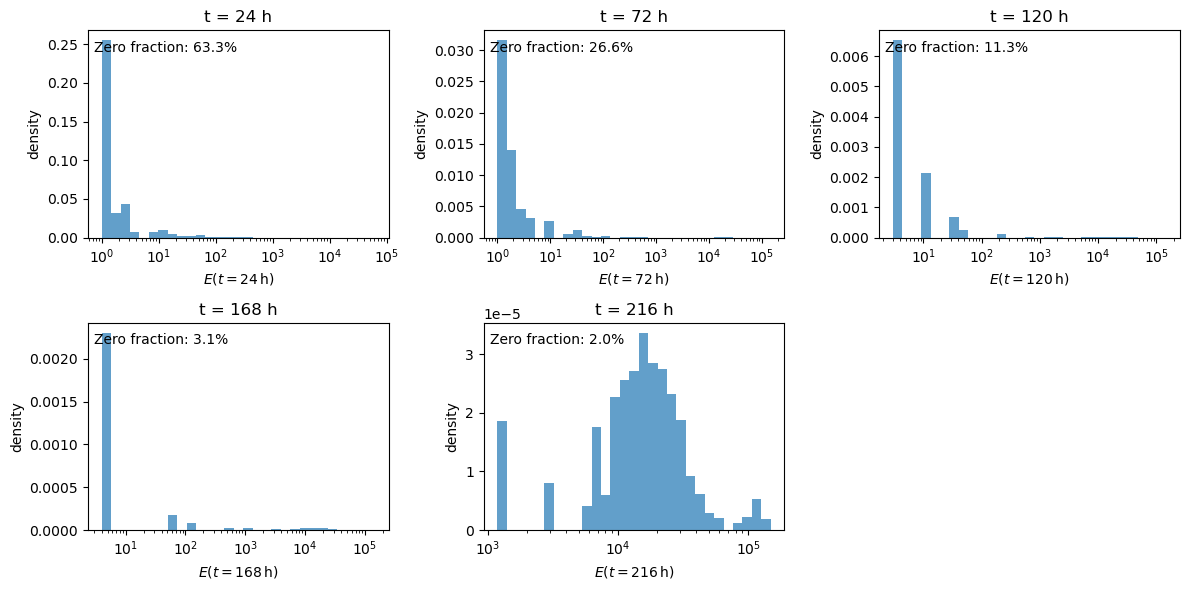

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

time_info = [(24, idx_24), (72, idx_72), (120, idx_120), (168, idx_168), (216, idx_216)]

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 3, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),  
    fig.add_subplot(gs[1, 1]),
]

for ax, (t_label, idx) in zip(axes, time_info):
    E_t = E_mat[idx, :]
    E_pos = E_t[E_t > 0]

    frac_zero = np.mean(E_t == 0)

    if E_pos.size == 0:
        # nothing positive to log-bin; show a simple note
        ax.text(0.5, 0.5, "No E > 0 samples", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"t = {t_label} h")
        ax.set_xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
        ax.set_ylabel("density")
        continue

    # log-spaced bins
    bins = np.logspace(np.log10(E_pos.min()), np.log10(E_pos.max()), 30)

    ax.hist(E_pos, bins=bins, density=True, alpha=0.7)
    ax.set_xscale("log")
    ax.set_xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
    ax.set_ylabel("density")
    ax.set_title(f"t = {t_label} h")

    ax.text(
        0.02, 0.95,
        f"Zero fraction: {frac_zero:.1%}",
        transform=ax.transAxes,
        ha="left", va="top"
    )

plt.tight_layout()
plt.show()


In [19]:
print("Total probability:", np.sum(p))
print("Mean capacity:", np.sum(kappa * p))
print("Median capacity:",
      kappa[np.searchsorted(np.cumsum(p), 0.5)])


Total probability: 1.0
Mean capacity: 38943.67394106427
Median capacity: 23995.0


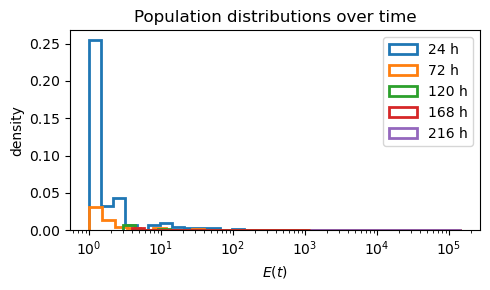

In [20]:
plt.figure(figsize=(5, 3))

for t_label, idx, alpha in [(24, idx_24, 0.4), (72, idx_72, 0.4), (120, idx_120, 0.4), (168, idx_168, 0.4), (216, idx_216, 0.4)]:
    E_t = E_mat[idx, :]
    E_pos = E_t[E_t > 0]

    bins = np.logspace(
        np.log10(E_pos.min()),
        np.log10(E_pos.max()),
        30
    )

    plt.hist(
        E_pos,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        label=f"{t_label} h",
    )

plt.xscale("log")
plt.xlabel(r"$E(t)$")
plt.ylabel("density")
plt.title("Population distributions over time")
plt.legend()
plt.tight_layout()
plt.show()
